# 02 – Exploratory Data Analysis

Quick visual inspection of the collected price series in both raw
probability space and logit space.

In [2]:
import sys, pathlib, logging
sys.path.insert(0, str(pathlib.Path.cwd().parent))
logging.basicConfig(level=logging.WARNING)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=0.9)

from src.config import DATA_PROCESSED, ALL_MARKETS

In [3]:
# Load feature tables
dfs = {}
for m in ALL_MARKETS:
    p = DATA_PROCESSED / f"features_{m['slug']}.parquet"
    if p.exists():
        dfs[m["slug"]] = pd.read_parquet(p)
        print(f"{m['slug']:40s}  {len(dfs[m['slug']]):>6d} rows")
    else:
        print(f"{m['slug']:40s}  NOT FOUND – run transform first")

will-donald-trump-win-the-2024-us-presidential-election    7333 rows
will-kamala-harris-win-the-popular-vote-in-the-2024-presidential-election    7212 rows
will-bitcoin-hit-100k-in-2024               6613 rows
will-bitcoin-hit-100k-again-in-2024-dec-23     184 rows
will-microstrategy-purchase-more-bitcoin-in-2024-dec-16     167 rows
oscars-best-picture-will-anora-win-best-picture-at-the-2025-oscars     951 rows
will-saquon-barkley-win-super-bowl-lix-mvp     376 rows
will-shai-gilgeous-alexander-win-the-2025-nba-finals-mvp    1497 rows
will-nikki-haley-win-the-2024-republican-iowa-caucus     145 rows


## Price time series (probability space)

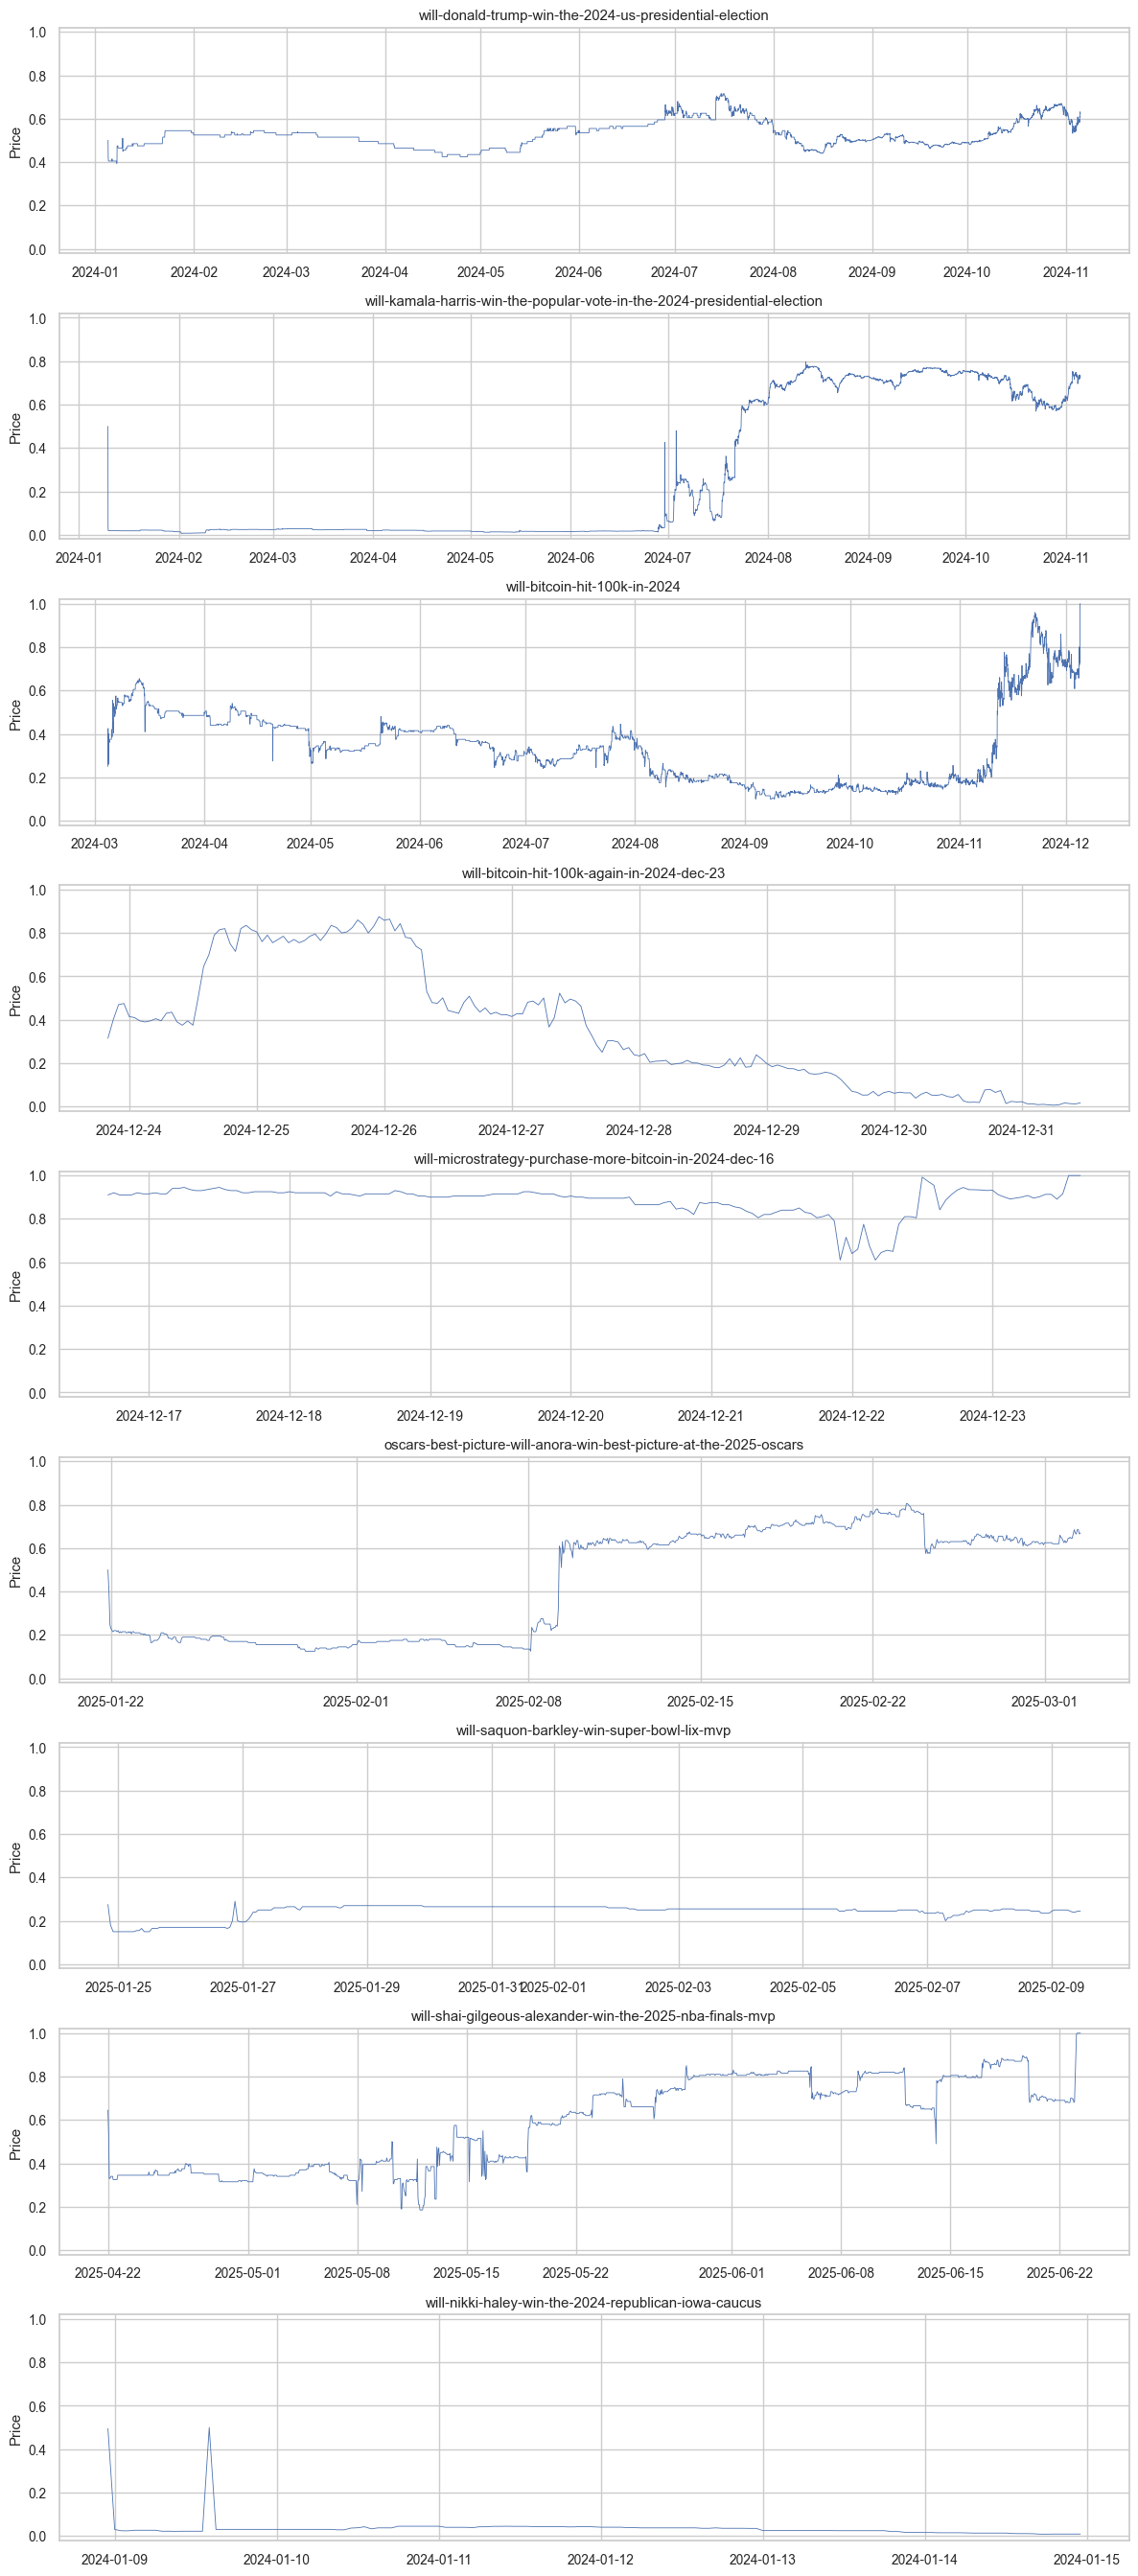

In [4]:
fig, axes = plt.subplots(len(dfs), 1, figsize=(12, 3 * len(dfs)), sharex=False)
if len(dfs) == 1:
    axes = [axes]
for ax, (slug, df) in zip(axes, dfs.items()):
    ax.plot(df["timestamp"], df["price"], linewidth=0.6)
    ax.set_ylabel("Price")
    ax.set_title(slug)
    ax.set_ylim(-0.02, 1.02)
fig.tight_layout()
plt.show()

## Logit-space price and returns

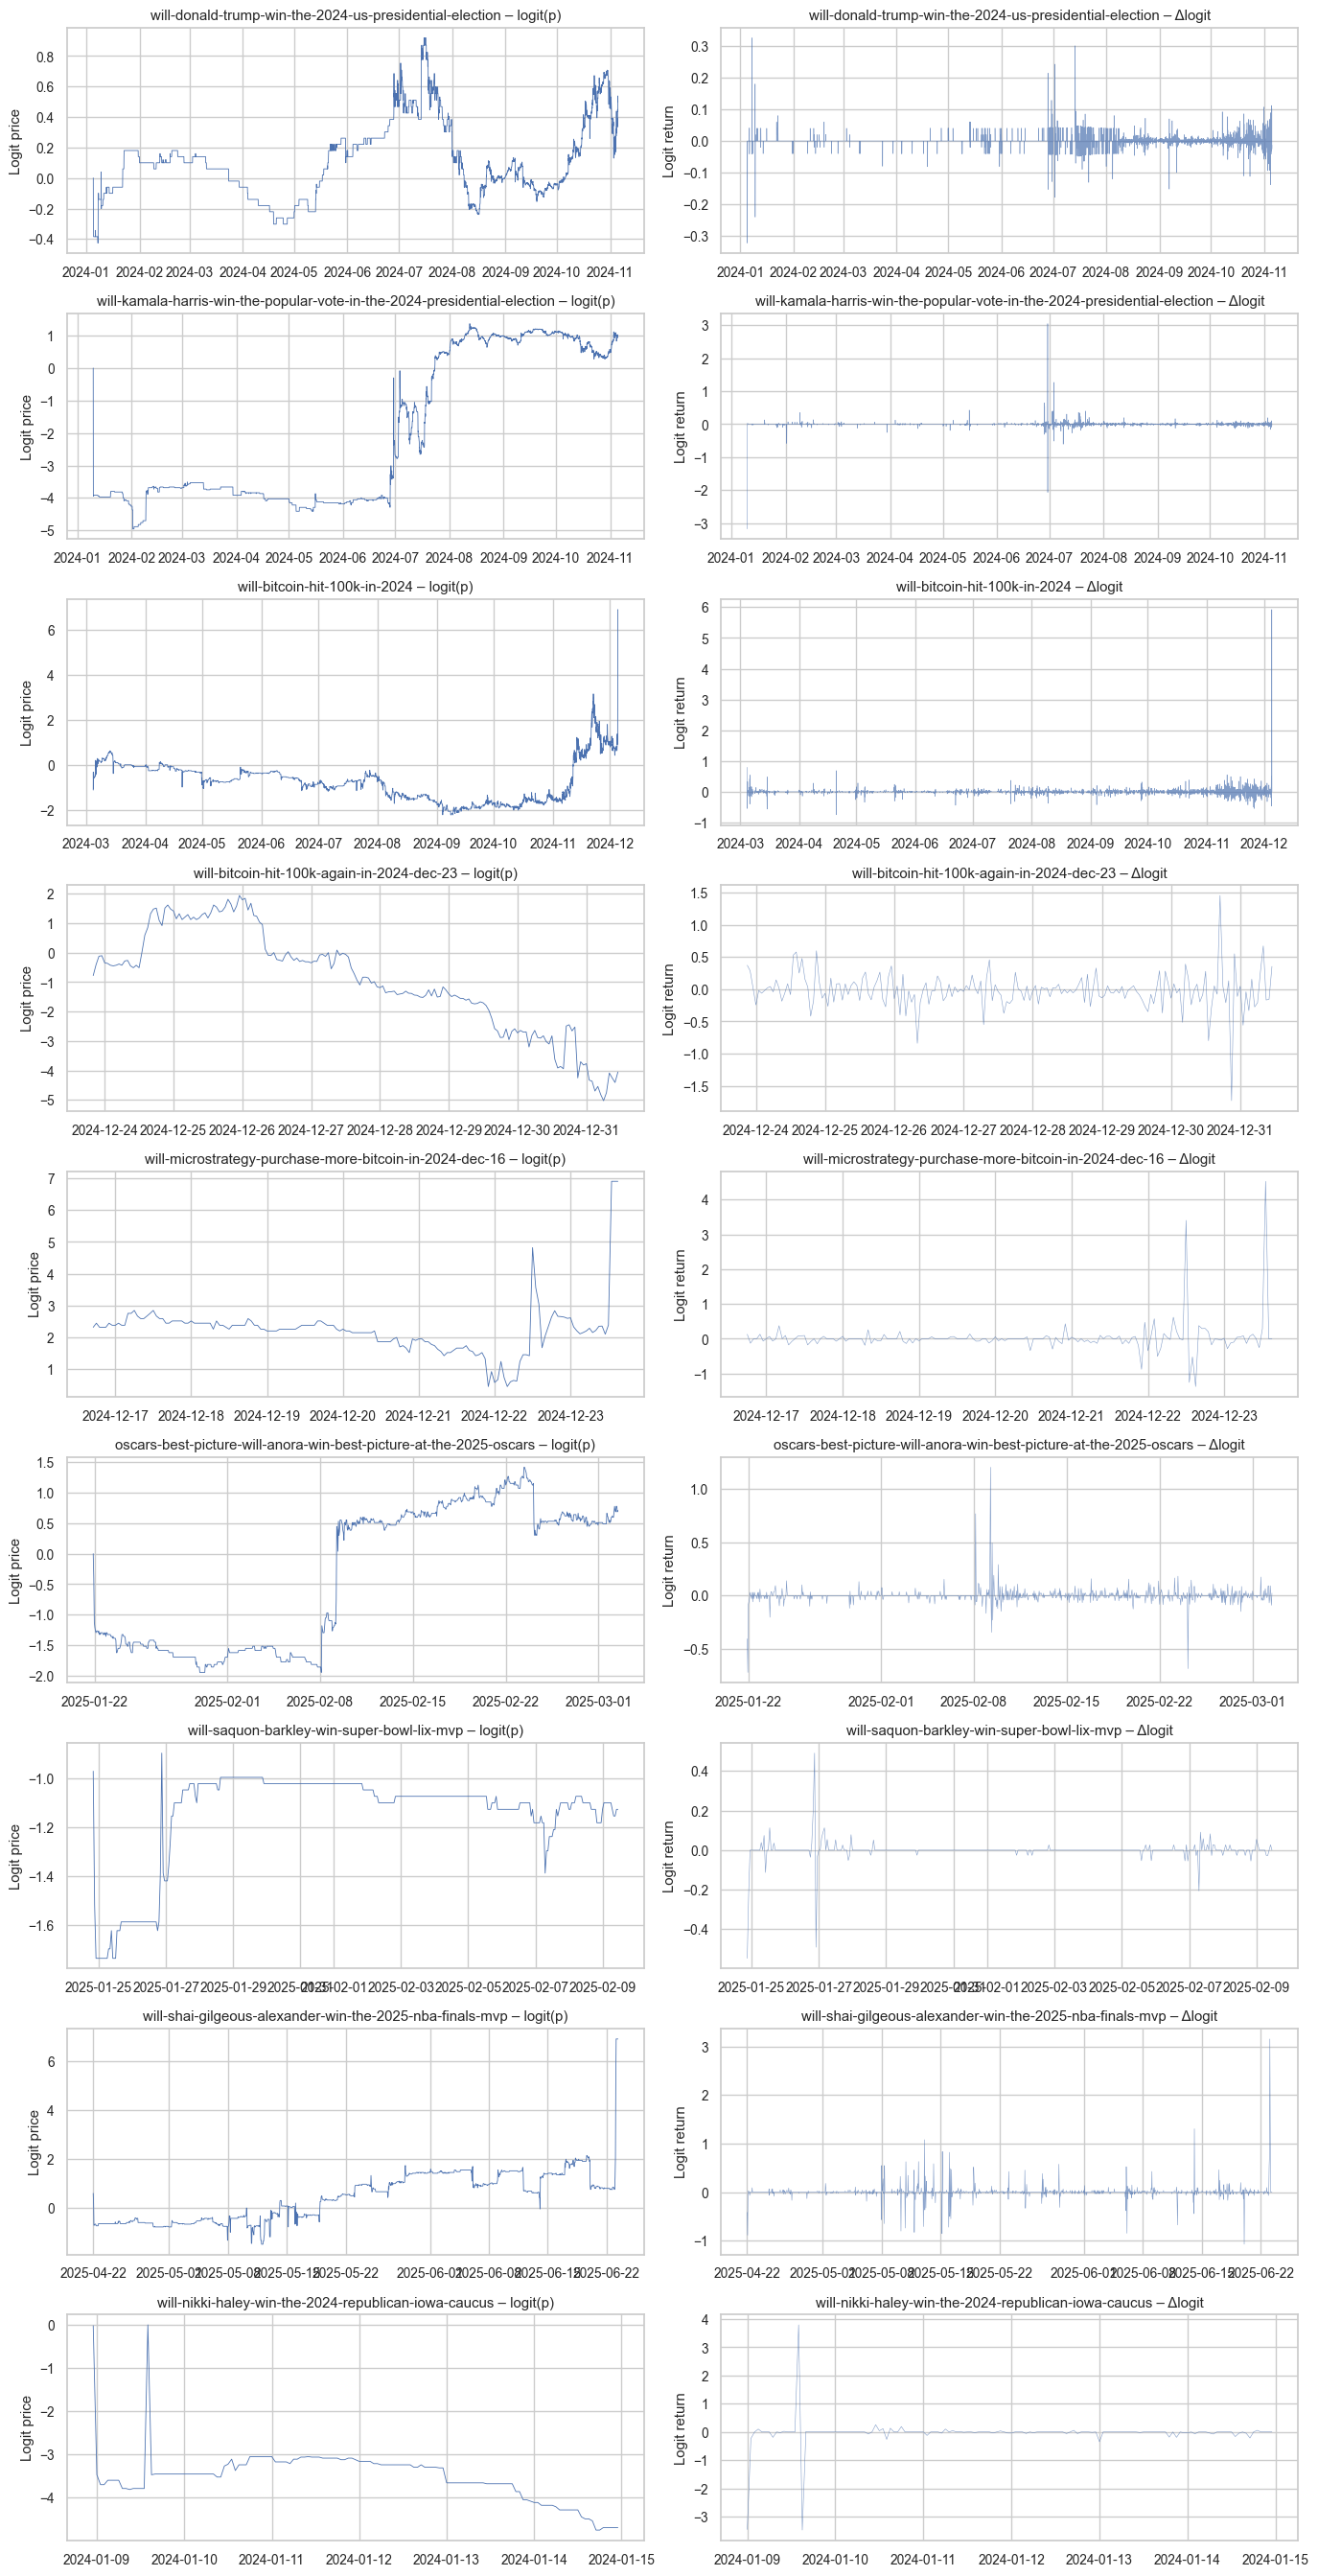

In [5]:
fig, axes = plt.subplots(len(dfs), 2, figsize=(14, 3 * len(dfs)))
if len(dfs) == 1:
    axes = axes.reshape(1, -1)
for i, (slug, df) in enumerate(dfs.items()):
    axes[i, 0].plot(df["timestamp"], df["logit_price"], linewidth=0.6)
    axes[i, 0].set_ylabel("Logit price")
    axes[i, 0].set_title(f"{slug} – logit(p)")

    axes[i, 1].plot(df["timestamp"], df["logit_return"], linewidth=0.4, alpha=0.7)
    axes[i, 1].set_ylabel("Logit return")
    axes[i, 1].set_title(f"{slug} – Δlogit")
fig.tight_layout()
plt.show()

## Activity proxies

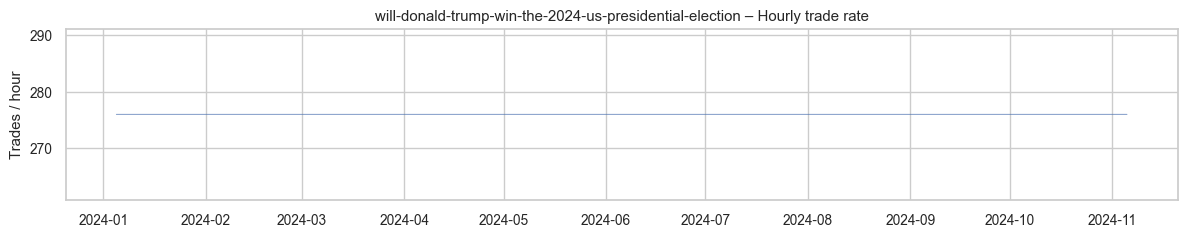

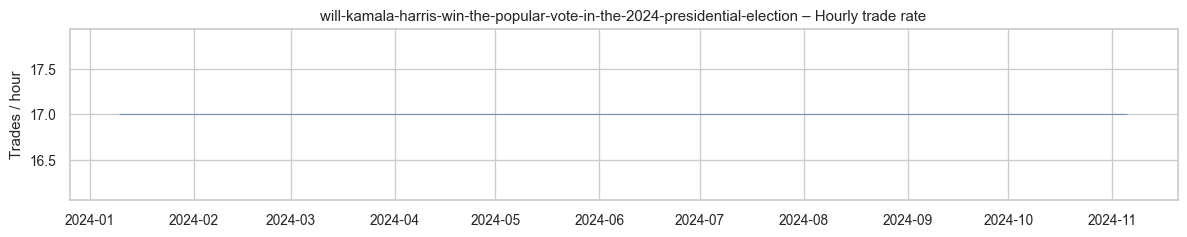

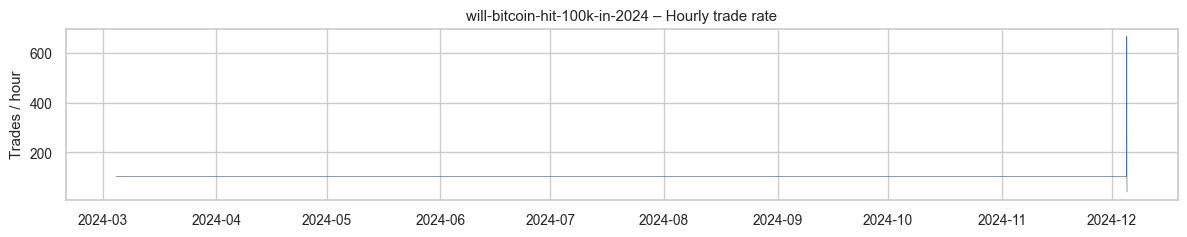

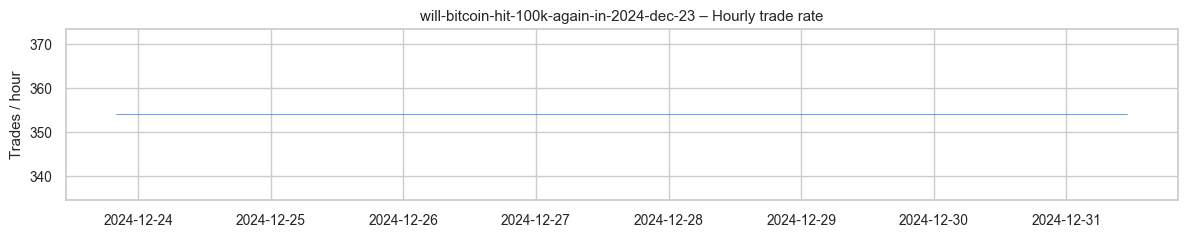

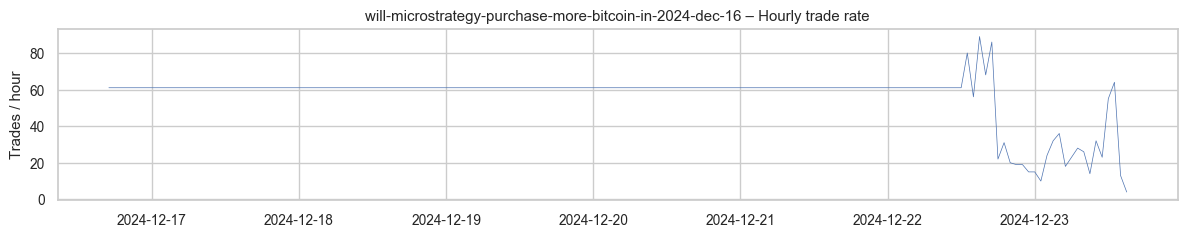

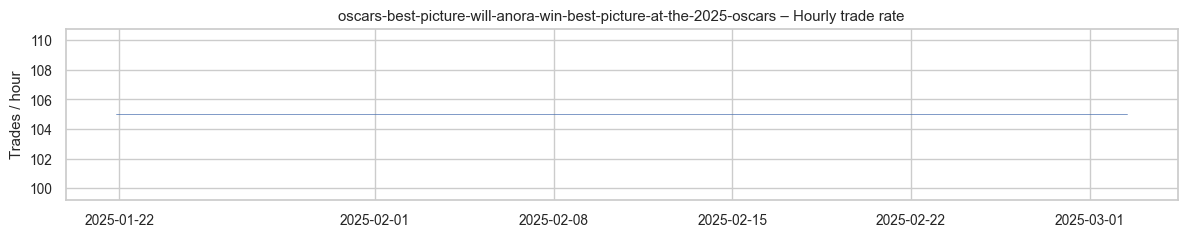

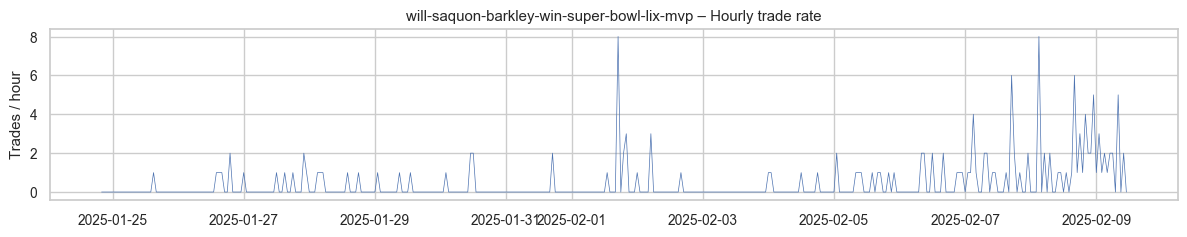

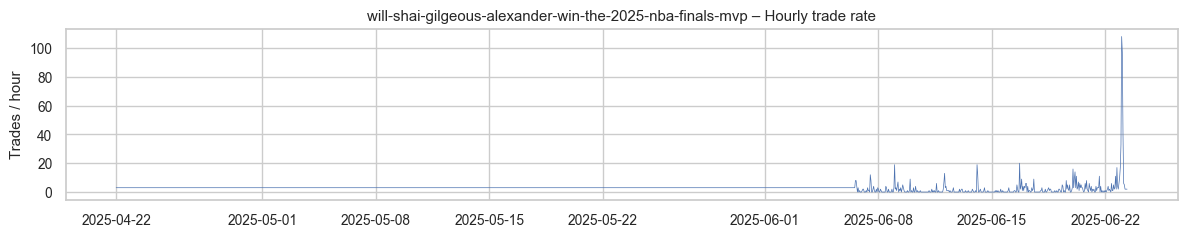

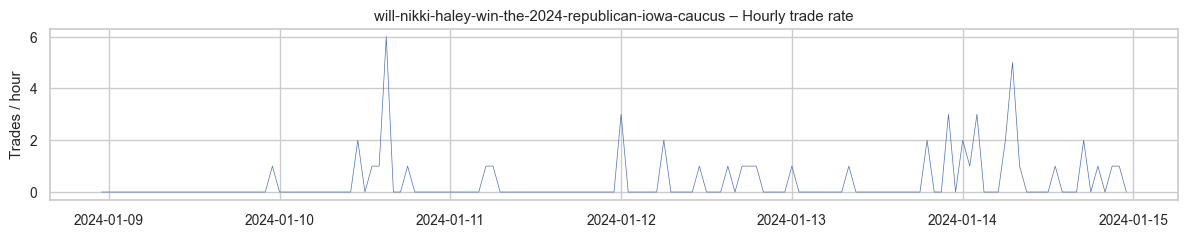

In [6]:
for slug, df in dfs.items():
    if "trade_rate_1h" not in df.columns:
        continue
    fig, ax = plt.subplots(figsize=(12, 2.5))
    ax.plot(df["timestamp"], df["trade_rate_1h"], linewidth=0.5)
    ax.set_ylabel("Trades / hour")
    ax.set_title(f"{slug} – Hourly trade rate")
    fig.tight_layout()
    plt.show()